In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import MDAnalysis as mda
from MDAnalysis.tests.datafiles import GRO, TRR
from MDAnalysis.analysis import contacts

In [3]:
u = mda.Universe("md.gro","md_center.trr")

In [4]:
sel1 = "(protein)"
sel2 = "(resname CU)"
ac = u.select_atoms(sel1)
ba = u.select_atoms(sel2)

In [5]:
def contacts_within_cutoff(u, group_a, group_b, radius=3.2):
    timeseries = []
    for ts in u.trajectory:
        # calculate distances between group_a and group_b
        dist = contacts.distance_array(group_a.positions, group_b.positions)
        # determine which distances <= radius
        n_contacts = contacts.contact_matrix(dist, radius).sum()
        timeseries.append([ts.frame, n_contacts])
    return np.array(timeseries)

In [6]:
ca = contacts_within_cutoff(u, ac, ba, radius=3)
ca.shape

(10001, 2)

In [7]:
ca_df = pd.DataFrame(ca, columns=['Frame',
                                  '# Contacts'])
ca_df.to_csv('file1.csv')

Text(0, 0.5, '# salt bridges')

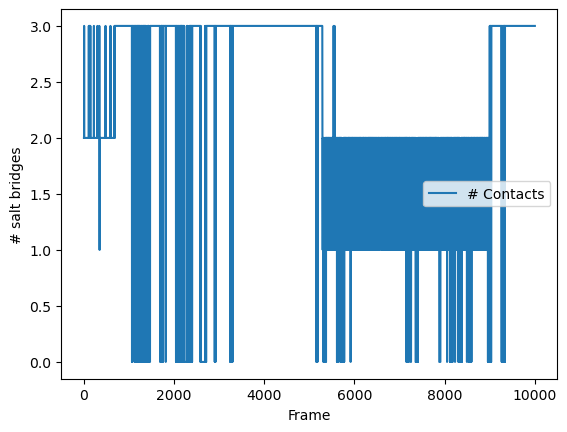

In [8]:
ca_df.plot(x='Frame')
plt.ylabel('# salt bridges')